# Tutorial 3 — Investment Study

## 1. Introduction to the study case

This tutorial explains how to handle **investment studies** in GEMS using the [GemsPy Python package](https://pypi.org/project/gemspy/).

We model a simple study case with:

- 1 **thermal plant** (with a capacity of 200 MW)
- 1 **renewable source** (time and scenario dependent)
- 1 **candidate thermal plant** (with a capacity to be assessed by the optimiser)
- 1 **load** (time and scenario dependent)

The optimiser finds the optimal capacity of the **candidate** plant to minimise total cost (investment + operational cost + unsupplied energy penalty).

### 1.1 Choice of the scenarios

We use **3 scenarios** and **4 timesteps**:

| Scenario | Load level | Renewable share | Without investment |
|---|---|---|---|
| **S1** — Favourable | Low (190–220 MW) | High (100–140 MW) | Adequate — no problem |
| **S2** — Critical | High (450–500 MW) | Low (20–40 MW) | ~220–275 MW unsupplied per timestep |
| **S3** — Intermediate | Medium (310–360 MW) | Medium (60–90 MW) | ~20–90 MW unsupplied per timestep |


Load (demand in MW) : 
| S1  | S2  | S3  |
| --- | --- | --- |
| 200 | 450 | 320 |
| 210 | 480 | 340 |
| 190 | 460 | 310 |
| 220 | 500 | 360 |

Renewable production (in MW) :
| S1  | S2  | S3  |
| --- | --- | --- |
| 120 |  30 |  80 |
| 100 |  20 |  60 |
| 140 |  40 |  90 |
| 110 |  25 |  70 |

### 1.2 Study file structure

The study folder is inside the [`Tutorial_3_Investment/`](../Tutorial_3_Investment/Tutorial_Investment/ -TODO link to zip folder)

The `basic-models-library` was used as a basis for creating the `investment_library.yml` where the new model **candidate_generator** was added.

<details>
<summary><strong>Details of the <code>candidate_generator</code> model</strong></summary>

**parameters:**
- `investment_cost` — time and scenario independent, represents the initial investment cost
- `generation_cost` — time and scenario independent, represents the operational cost

**variables:**
- `p_installed` — the installed power capacity chosen by the optimiser; constant across time and scenarios, but *generation* will fluctuate
- `generation` — the actual power generation of the thermal candidate; cannot exceed `p_installed`

</details>

<details>
<summary><strong>⚠️ Warning — optim config file</strong></summary>

As we are running the study by GemsPy default **frontal** mode, we don't configure any `optim-config.yml` file.

Learn more about the GemsPy `optim-config.yml` file [in its documentation](https://gemspy.readthedocs.io/en/latest/user-guide/optim-config/).

</details>

## 2. Running the study
### 2.1 Installation of the required libraries

In [6]:
# Install required libraries
%pip install gemspy matplotlib --quiet --upgrade

Note: you may need to restart the kernel to use updated packages.


### 2.2 Load and solve the study

In [8]:
from pathlib import Path
from gems.study.folder import load_study
from gems.session.session import SimulationSession
from gems.optim_config.parsing import OptimConfig, TimeScopeConfig, ScenarioScopeConfig

_cwd = Path.cwd()
study_dir = _cwd / "Tutorial_Investment"

print("STUDY LOADING")
study = load_study(study_dir)
print("\tStudy loaded")

optim_config = OptimConfig(
    time_scope=TimeScopeConfig(first_time_step=0, last_time_step=3),
    scenario_scope=ScenarioScopeConfig(nb_scenarios=3),
)

print("\nSOLVING OPTIMIZATION PROBLEM")
result = SimulationSession(study=study, optim_config=optim_config).run()
print("\tOptimization problem solved")

STUDY LOADING
	Study loaded

SOLVING OPTIMIZATION PROBLEM


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'objective' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'expected_operating_cost' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
ERROR:   getOptionIndex: Option "solver_logs" is unknown
LP has 36 rows; 49 cols; 120 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e-01, 3e+03]
  Bound   [2e+02, 2e+02]
  RHS     [5e+01, 5e+02]
Presolving model
36 rows, 49 cols, 120 nonzeros 0s
Dependent equations search running on 8 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
16 rows, 25 cols, 40 nonzeros 0s
Presolve reductions: rows 16(-20); columns 25(-24); nonzeros 40(-80) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     3.5000000000e+03 Pr: 8(2805) 0.0s
          9     5.3333333333e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 9
Objective value     :  5.3333333333e+04
P-D

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


## 3. Results Analysis

### 3.1 Constant output ; *p_installed*

Let's verify that the *p_installed* capacity is fit for tackling the load.

In the simulation-table, the amount this capacity is **275 MW** similar to the highest unsupplied energy amount (scenario 2, timestep 4)

So, the *p_installed* optimised value is well suitable to our study.

### 3.2 Scenario/Time dependent outputs

As mentionned in the introduction, the result variables (`generation`, `unsupplied_energy`) are not constant. They fluctuate over the time and can differ across scenarios.

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.p

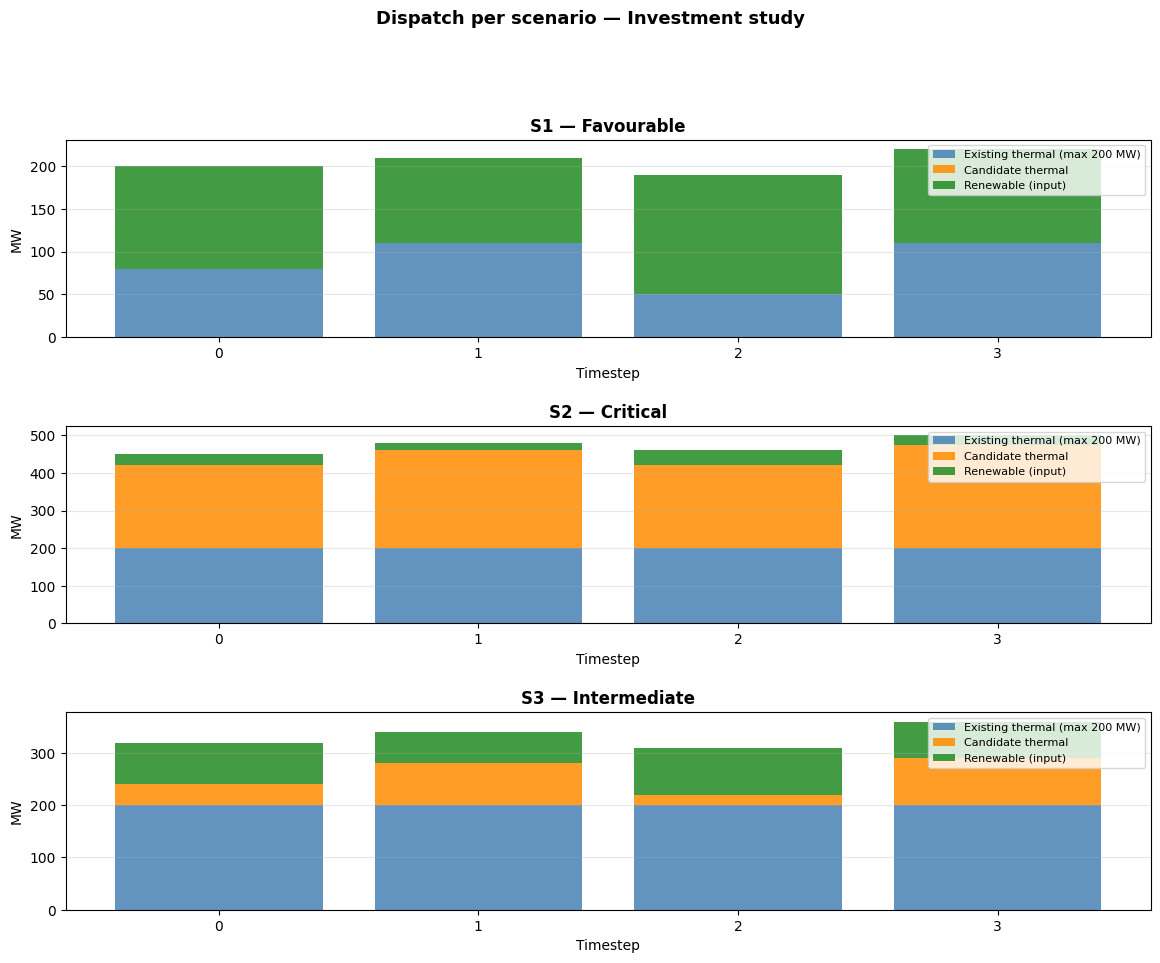

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, base64
from IPython.display import display

# Renewable generation is a parameter (input), not a variable — read from file directly
renewable_data = np.loadtxt(study_dir / "input/data-series/renewable_gen.txt")

scenario_labels = ["S1 — Favourable", "S2 — Critical", "S3 — Intermediate"]
timesteps = list(range(4))

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

for s, label in enumerate(scenario_labels):
    ax = fig.add_subplot(gs[s])

    existing_gen  = result.component("thermal_existing").output("generation").value(scenario_index=s).values
    candidate_gen = result.component("candidate_thermal").output("generation").value(scenario_index=s).values
    renewable_gen = renewable_data[:, s]
    unsupplied    = result.component("node").output("unsupplied_energy").value(scenario_index=s).values

    ax.bar(timesteps, existing_gen,  label="Existing thermal (max 200 MW)", color="steelblue",   alpha=0.85)
    ax.bar(timesteps, candidate_gen, label="Candidate thermal",              color="darkorange",  alpha=0.85,
           bottom=existing_gen)
    ax.bar(timesteps, renewable_gen, label="Renewable (input)",              color="forestgreen", alpha=0.85,
           bottom=existing_gen + candidate_gen)

    if any(u > 0.1 for u in unsupplied):
        ax.plot(timesteps, unsupplied, "rv--", linewidth=1.5, markersize=6, label="Unsupplied energy")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("MW")
    ax.set_xticks(timesteps)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Dispatch per scenario — Investment study", fontsize=13, fontweight="bold", y=1.01)

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
display(
    {"image/png": base64.b64encode(buf.read()).decode()},
    raw=True,
    metadata={"image/png": {"alt": "Stacked bar charts showing dispatch (existing thermal, candidate thermal, renewable) for each of the 3 scenarios across 4 timesteps."}}
)
plt.close(fig)

## Interpretation

With **275 MW** of candidate capacity installed:

- **S1** (favourable): existing thermal + renewables are sufficient — the candidate plant generates
  little or nothing; some spillage may occur.
- **S2** (critical): the candidate plant runs at or near full capacity to cover the high demand.
  The binding timestep is t=3 (demand 500 MW, renewable 25 MW → exactly covered).
- **S3** (intermediate): the candidate plant covers the remaining gap after existing thermal and
  renewables.

**Sensitivity**: try lowering `unsupplied_energy_cost` in `system.yml` (e.g. from 10 000 to 500 €/MWh).
At some threshold, accepting a small amount of unsupplied energy in S2 becomes cheaper than
installing the marginal MW — and `p_installed` will drop below 275 MW.